# Supply Chain & Logística Inteligente com IA

## Segmentação de Clientes Logísticos e Detecção de Anomalias Operacionais

**Autor:** Fábio Andrade  
**Disciplina:** Supply Chain & Logística Inteligente com IA  
**Tipo:** Projeto final acadêmico  
**Ambiente de execução:** Google Colab  
**Repositório:** [supply-chain-clustering-anomaly-ai](https://github.com/thedrads/supply-chain-clustering-anomaly-ai)

### Linha escolhida

**Identificação de Clusters e Detecção de Anomalia**

### Objetivo do projeto

Aplicar técnicas de análise de dados e machine learning para segmentar clientes logísticos, identificar comportamentos fora do padrão e gerar insights gerenciais sobre custo logístico, nível de serviço, risco operacional e priorização de clientes.

## Preparação do ambiente

**Objetivo:** importar as bibliotecas necessárias para análise dos dados, visualização, clusterização e detecção de anomalias.

Essas ferramentas serão utilizadas durante todo o pipeline analítico do projeto.

In [4]:
# Importa bibliotecas para manipulação de dados.
import numpy as np
import pandas as pd

# Importa bibliotecas para visualização.
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Importa recursos para clusterização e detecção de anomalias.
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Configura a apresentação das tabelas e dos gráficos.
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")

# Define a semente para permitir resultados reproduzíveis.
random_state = 42

## Carregamento da base de dados

**Objetivo:** carregar a base sintética de clientes logísticos diretamente do GitHub.

A leitura pela URL pública torna o notebook reproduzível e elimina a necessidade de Google Drive ou upload manual.

In [5]:
# Define a localização pública da base sintética no GitHub.
dataset_url = (
    "https://raw.githubusercontent.com/thedrads/"
    "supply-chain-clustering-anomaly-ai/main/data/synthetic/"
    "clientes_logisticos_sinteticos_supply_chain.csv"
)

# Carrega os dados diretamente para um DataFrame.
clientes_df = pd.read_csv(dataset_url)

# Confirma as dimensões da base carregada.
print(
    f"Base carregada: {clientes_df.shape[0]} linhas e "
    f"{clientes_df.shape[1]} colunas."
)

Base carregada: 6000 linhas e 23 colunas.


## Visão inicial da base

**Objetivo:** visualizar os primeiros registros para conferir a estrutura, as colunas e os valores da base carregada.

In [6]:
# Exibe os cinco primeiros registros da base.
clientes_df.head()

,cliente_id,regiao,segmento_negocio,canal_relacionamento,porte_cliente,distancia_cd_km,volume_medio_entregue_kg,entregas_mes,ticket_medio_rs,receita_mensal_estimada_rs,lead_time_medio_dias,entregas_no_prazo_pct,custo_medio_entrega_rs,custo_logistico_mensal_rs,custo_por_kg_rs,taxa_ocorrencias_pct,variabilidade_demanda_pct,pedidos_urgentes_pct,prioridade_contrato,risco_operacional_score,anomalia_sintetica,tipo_anomalia_sintetica,cluster_teorico_sintetico
0,CLI_00001,Sul,Varejo,Marketplace,Pequeno,105.50,81.60,4,"2,328.61","9,314.42",3.47,99.11,325.95,"1,303.80",3.99,11.89,50.13,38.27,Baixa,27.32,0,normal,Baixo volume instável
1,CLI_00002,Sudeste,Indústria,Distribuidor,Grande,134.60,584.80,10,"4,243.14","42,431.38",2.83,97.21,280.25,"2,802.50",0.48,5.87,25.38,22.12,Média,18.20,0,normal,Recorrentes padrão
2,CLI_00003,Sudeste,Varejo,Venda direta,Grande,130.90,281.80,7,"1,838.57","12,870.01",3.46,87.31,280.49,"1,963.43",1.00,6.14,49.63,58.62,Baixa,32.70,0,normal,Baixo volume instável
3,CLI_00004,Nordeste,E-commerce,Distribuidor,Pequeno,379.30,917.80,7,"5,833.62","40,835.36",4.88,84.35,707.91,"4,955.37",0.77,6.01,22.65,25.58,Média,31.94,0,normal,Longa distância alto custo
4,CLI_00005,Sudeste,Varejo,B2B,Pequeno,61.10,"1,539.20",19,"10,152.08","192,889.60",1.36,95.39,209.20,"3,974.80",0.14,0.69,7.35,10.15,Alta,8.75,0,normal,Estratégicos urbanos


## Estrutura e tipos dos dados

**Objetivo:** examinar a estrutura do DataFrame, os tipos das variáveis e a quantidade de valores preenchidos em cada coluna.

In [7]:
# Apresenta a estrutura, os tipos e o preenchimento das colunas.
clientes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cliente_id                  6000 non-null   object 
 1   regiao                      6000 non-null   object 
 2   segmento_negocio            6000 non-null   object 
 3   canal_relacionamento        6000 non-null   object 
 4   porte_cliente               6000 non-null   object 
 5   distancia_cd_km             6000 non-null   float64
 6   volume_medio_entregue_kg    6000 non-null   float64
 7   entregas_mes                6000 non-null   int64  
 8   ticket_medio_rs             6000 non-null   float64
 9   receita_mensal_estimada_rs  6000 non-null   float64
 10  lead_time_medio_dias        6000 non-null   float64
 11  entregas_no_prazo_pct       6000 non-null   float64
 12  custo_medio_entrega_rs      6000 non-null   float64
 13  custo_logistico_mensal_rs   6000 

## Verificação de integridade

**Objetivo:** verificar valores ausentes, linhas duplicadas e identificadores de clientes repetidos.

Essa validação evita que problemas de qualidade comprometam as análises e os modelos posteriores.

In [8]:
# Conta todos os valores ausentes da base.
total_valores_ausentes = clientes_df.isna().sum().sum()

# Verifica linhas e identificadores duplicados.
total_linhas_duplicadas = clientes_df.duplicated().sum()
total_ids_duplicados = clientes_df["cliente_id"].duplicated().sum()

# Apresenta o resumo da verificação.
print(f"Valores ausentes: {total_valores_ausentes}")
print(f"Linhas duplicadas: {total_linhas_duplicadas}")
print(f"IDs de cliente duplicados: {total_ids_duplicados}")

Valores ausentes: 0
Linhas duplicadas: 0
IDs de cliente duplicados: 0


## Análise exploratória dos dados

### Estatísticas descritivas

**Objetivo:** analisar medidas de posição, dispersão e amplitude das variáveis numéricas operacionais.

A coluna de auditoria `anomalia_sintetica` será excluída desta análise para evitar influência prematura na interpretação.

In [9]:
# Seleciona variáveis numéricas e exclui a coluna de auditoria.
colunas_numericas_eda = (
    clientes_df.select_dtypes(include="number")
    .columns.drop("anomalia_sintetica")
)

# Calcula as principais estatísticas descritivas.
estatisticas_descritivas = (
    clientes_df[colunas_numericas_eda]
    .describe()
    .T
    .round(2)
)

# Exibe o resumo estatístico.
estatisticas_descritivas

,count,mean,std,min,25%,50%,75%,max
distancia_cd_km,"6,000.00",155.79,129.76,5.00,59.70,108.70,220.72,"1,131.14"
volume_medio_entregue_kg,"6,000.00",745.44,432.62,30.00,425.88,683.95,971.25,"2,285.30"
entregas_mes,"6,000.00",10.06,5.62,1.00,6.00,9.00,13.00,32.00
ticket_medio_rs,"6,000.00","5,010.15","2,808.58",250.00,"3,085.52","4,541.07","6,345.54","15,492.16"
receita_mensal_estimada_rs,"6,000.00","61,718.67","63,309.04",500.00,"19,402.21","39,205.98","69,774.60","328,081.95"
lead_time_medio_dias,"6,000.00",3.14,1.69,0.50,1.90,2.67,4.03,21.26
entregas_no_prazo_pct,"6,000.00",87.64,9.84,35.24,83.80,89.93,94.53,99.50
custo_medio_entrega_rs,"6,000.00",370.83,221.81,60.00,222.32,282.48,483.04,"2,914.27"
custo_logistico_mensal_rs,"6,000.00","3,283.12","2,014.09",147.15,"1,896.07","2,997.62","4,282.34","30,012.86"
custo_por_kg_rs,"6,000.00",0.86,1.49,0.06,0.27,0.53,1.01,63.58


### Leitura inicial das estatísticas

- A distância e a receita mensal apresentam médias superiores às medianas, indicando distribuições assimétricas e clientes com valores elevados.
- O custo por quilograma possui mediana de R$ 0,53 e máximo de R$ 63,58, sinalizando operações extremas que deverão ser investigadas.
- O lead time máximo de 21,26 dias e a pontualidade mínima de 35,24% indicam possíveis situações críticas de nível de serviço.
- A variabilidade da demanda, os pedidos urgentes e o risco operacional alcançam valores elevados em parte da base, sugerindo maior pressão logística nesses clientes.

Esses resultados são sinais exploratórios e ainda não confirmam anomalias ou relações de causa e efeito.

### Distribuição das variáveis categóricas

**Objetivo:** analisar a quantidade e a participação percentual dos clientes em cada categoria operacional.

As colunas sintéticas de auditoria não serão utilizadas nesta etapa exploratória.

In [10]:
# Define as variáveis categóricas operacionais.
colunas_categoricas_eda = [
    "regiao",
    "segmento_negocio",
    "canal_relacionamento",
    "porte_cliente",
    "prioridade_contrato",
]

# Prepara os resumos de quantidade e participação percentual.
resumos_categoricos = []

for coluna in colunas_categoricas_eda:
    contagem = clientes_df[coluna].value_counts()

    resumo_coluna = pd.DataFrame(
        {
            "variavel": coluna,
            "categoria": contagem.index,
            "quantidade": contagem.values,
            "percentual": (
                contagem.values / len(clientes_df) * 100
            ).round(2),
        }
    )

    resumos_categoricos.append(resumo_coluna)

# Consolida os resultados em uma única tabela.
distribuicao_categoricas = pd.concat(
    resumos_categoricos,
    ignore_index=True,
)

distribuicao_categoricas

,variavel,categoria,quantidade,percentual
0,regiao,Sudeste,2241,37.35
1,regiao,Sul,1193,19.88
2,regiao,Nordeste,1112,18.53
3,regiao,Centro-Oeste,782,13.03
4,regiao,Norte,672,11.20
5,segmento_negocio,Varejo,1920,32.00
6,segmento_negocio,Atacado,1309,21.82
7,segmento_negocio,Indústria,1086,18.10
8,segmento_negocio,E-commerce,1073,17.88
9,segmento_negocio,Serviços,612,10.20


### Leitura das variáveis categóricas

- A região Sudeste concentra 37,35% dos clientes, enquanto a região Norte representa 11,20%. Essa diferença deve ser considerada nas comparações regionais.
- O Varejo é o segmento mais frequente, com 32,00% da base, seguido pelo Atacado, com 21,82%.
- O canal B2B possui a maior participação, representando 42,28% dos relacionamentos.
- Clientes pequenos e médios correspondem, juntos, a 82,28% do portfólio analisado.
- Contratos de prioridade média, alta ou premium representam aproximadamente 84,11% da base.

Como a base é sintética, essa composição representa um cenário acadêmico e não a distribuição de uma empresa ou mercado real.

### Distribuição das principais variáveis numéricas

**Objetivo:** visualizar o formato das distribuições de indicadores econômicos, operacionais, de serviço e de risco.

Os histogramas ajudam a identificar assimetrias e possíveis valores extremos, mas não confirmam anomalias isoladamente.

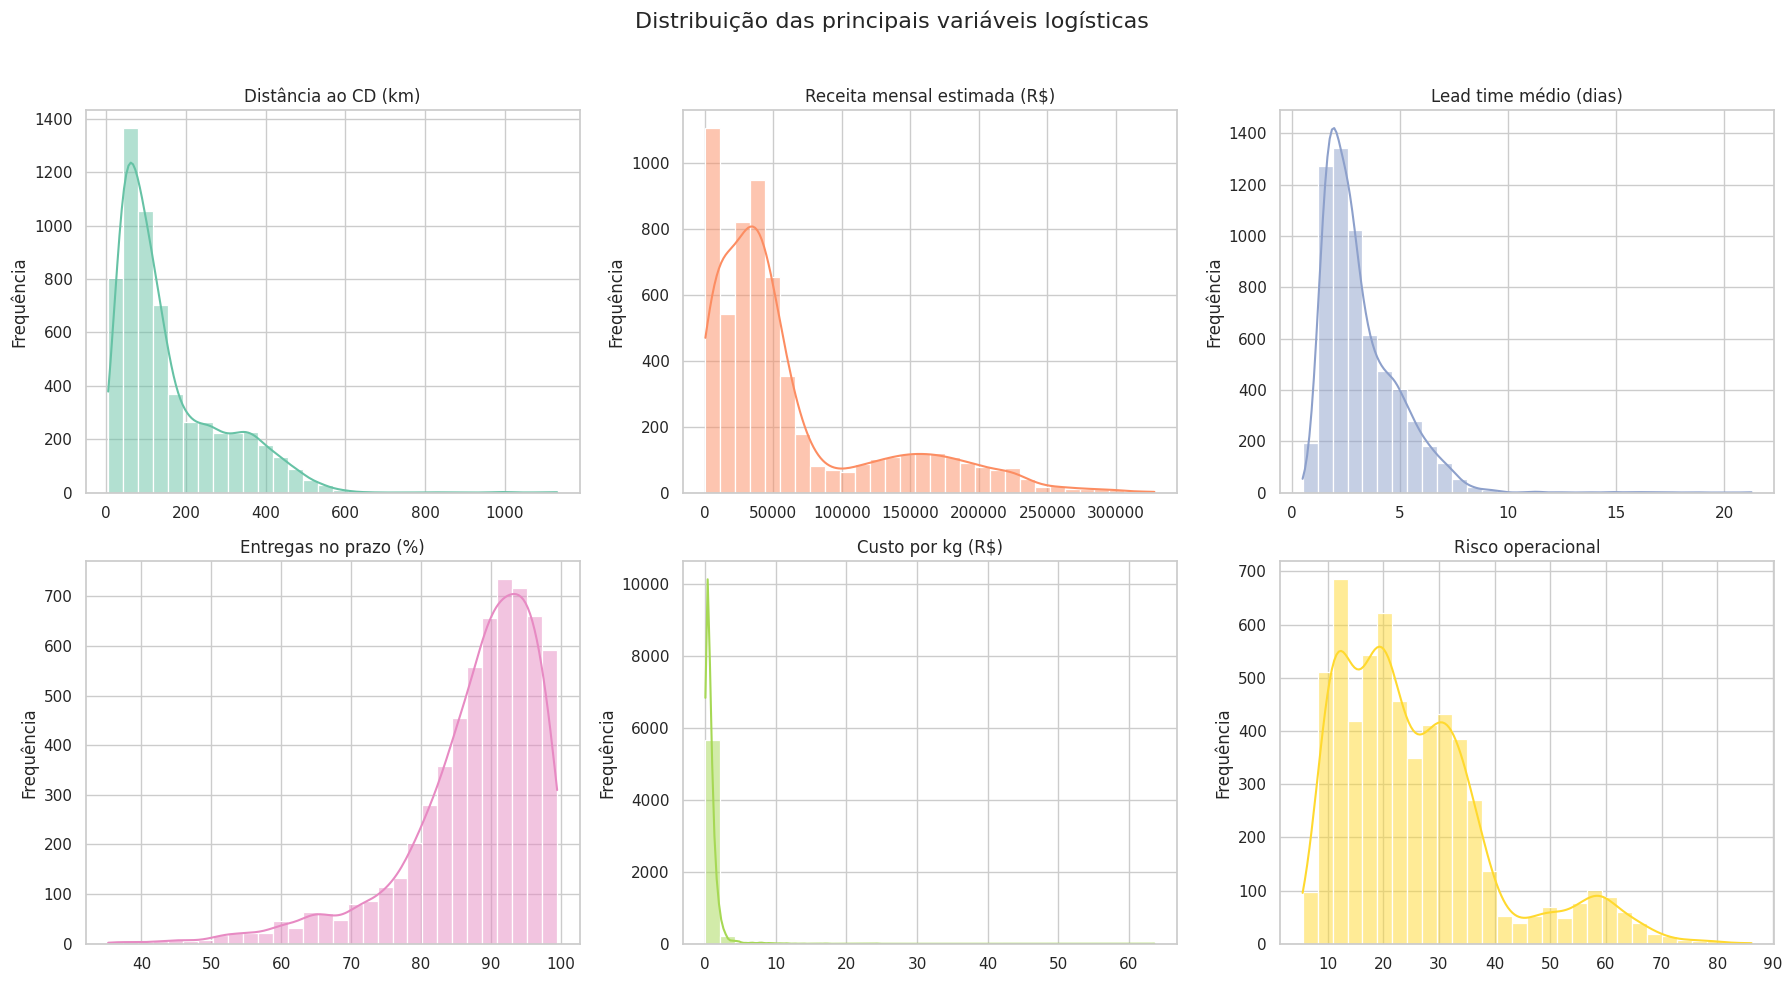

In [11]:
# Define as variáveis e os títulos dos gráficos.
variaveis_distribuicao = {
    "distancia_cd_km": "Distância ao CD (km)",
    "receita_mensal_estimada_rs": "Receita mensal estimada (R$)",
    "lead_time_medio_dias": "Lead time médio (dias)",
    "entregas_no_prazo_pct": "Entregas no prazo (%)",
    "custo_por_kg_rs": "Custo por kg (R$)",
    "risco_operacional_score": "Risco operacional",
}

# Cria a grade de histogramas.
fig, eixos = plt.subplots(2, 3, figsize=(18, 10))
cores = sns.color_palette("Set2", n_colors=6)

for eixo, (coluna, titulo), cor in zip(
    eixos.flat,
    variaveis_distribuicao.items(),
    cores,
):
    sns.histplot(
        data=clientes_df,
        x=coluna,
        bins=30,
        kde=True,
        color=cor,
        ax=eixo,
    )
    eixo.set_title(titulo)
    eixo.set_xlabel("")
    eixo.set_ylabel("Frequência")

# Ajusta o título e o espaçamento da figura.
fig.suptitle(
    "Distribuição das principais variáveis logísticas",
    fontsize=16,
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Leitura das distribuições

- A distância ao centro de distribuição apresenta assimetria à direita: a maior parte dos clientes está em distâncias menores, mas existe uma cauda com operações acima de 600 km.
- A receita mensal mostra grupos com diferentes faixas econômicas, reforçando a possibilidade de segmentação dos clientes.
- O lead time concentra-se principalmente entre 1 e 5 dias, com poucos casos muito elevados. A pontualidade apresenta comportamento inverso, concentrando-se em níveis altos, mas com uma cauda de baixo desempenho.
- O custo por quilograma possui forte assimetria e poucos valores muito distantes do padrão, tornando-se uma variável importante para a detecção de anomalias.
- O risco operacional apresenta diferentes concentrações e um grupo menor de clientes com risco elevado, indicando potencial para segmentação e priorização gerencial.

Os padrões observados justificam o uso posterior de padronização, clusterização e métodos específicos de detecção de anomalias.

### Boxplots dos indicadores logísticos

**Objetivo:** visualizar a amplitude, os quartis e os possíveis valores extremos dos principais indicadores operacionais.

Os pontos além dos limites dos boxplots representam casos para investigação, mas não devem ser classificados automaticamente como anomalias.

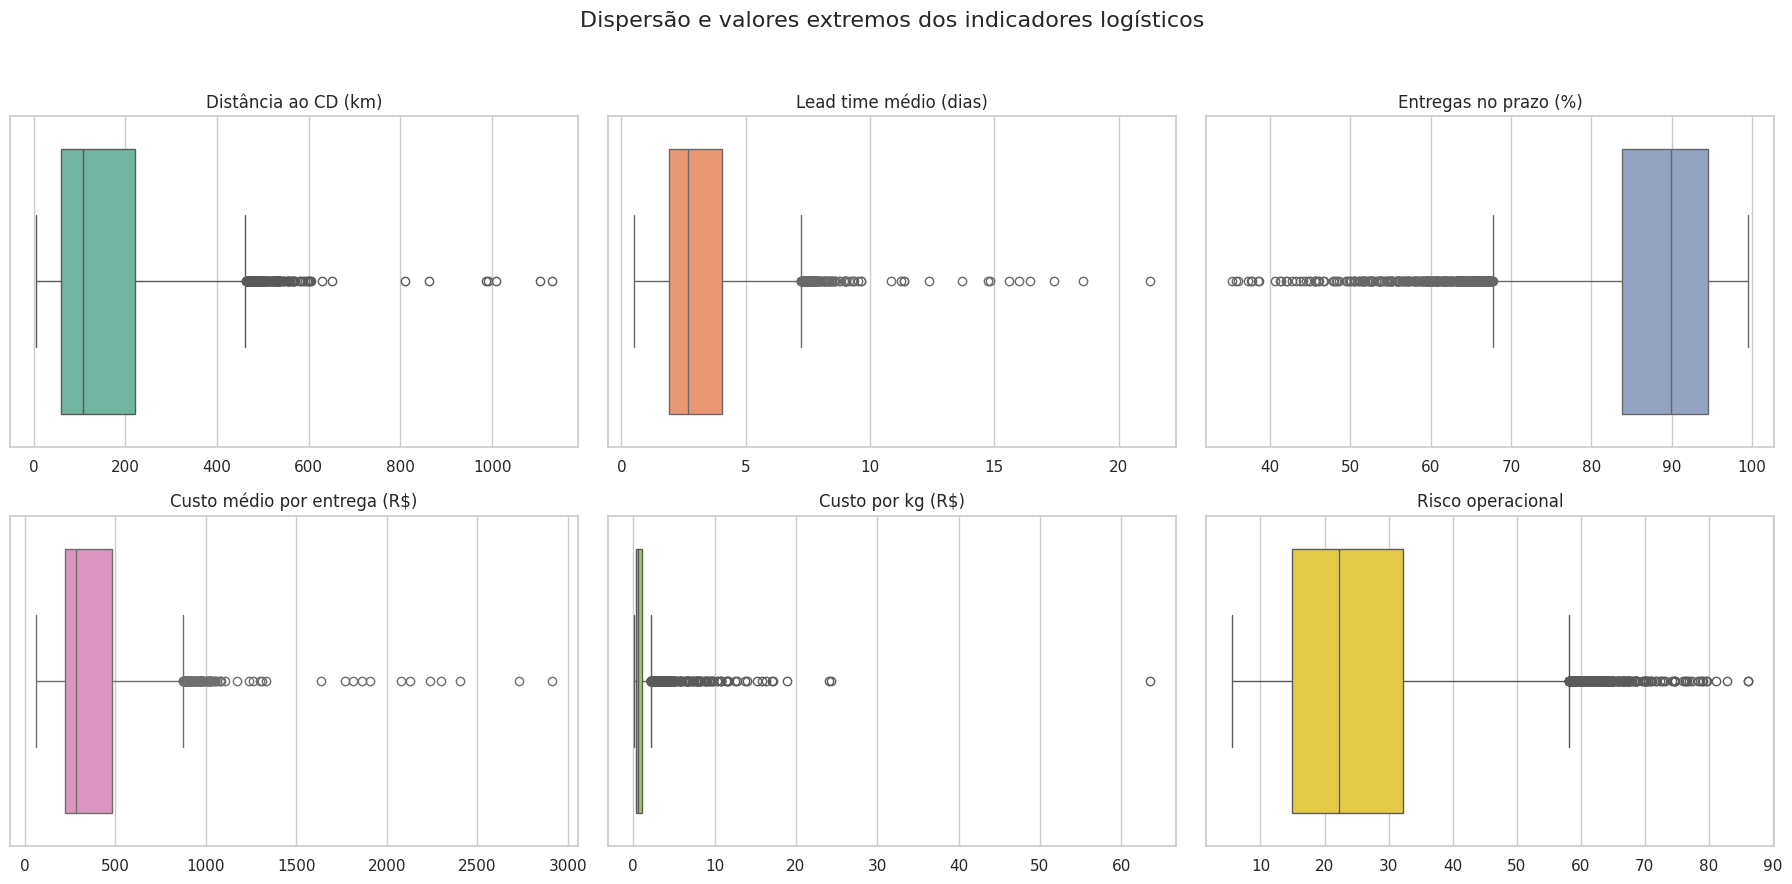

In [12]:
# Define as variáveis e os títulos dos boxplots.
variaveis_boxplot = {
    "distancia_cd_km": "Distância ao CD (km)",
    "lead_time_medio_dias": "Lead time médio (dias)",
    "entregas_no_prazo_pct": "Entregas no prazo (%)",
    "custo_medio_entrega_rs": "Custo médio por entrega (R$)",
    "custo_por_kg_rs": "Custo por kg (R$)",
    "risco_operacional_score": "Risco operacional",
}

# Cria a grade de boxplots.
fig, eixos = plt.subplots(2, 3, figsize=(18, 9))
cores = sns.color_palette("Set2", n_colors=6)

for eixo, (coluna, titulo), cor in zip(
    eixos.flat,
    variaveis_boxplot.items(),
    cores,
):
    sns.boxplot(
        data=clientes_df,
        x=coluna,
        color=cor,
        ax=eixo,
    )
    eixo.set_title(titulo)
    eixo.set_xlabel("")

# Ajusta o título e o espaçamento da figura.
fig.suptitle(
    "Dispersão e valores extremos dos indicadores logísticos",
    fontsize=16,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Leitura dos boxplots

- Distância e custo médio por entrega apresentam diversos valores acima do padrão, possivelmente associados a rotas mais longas ou operações mais complexas.
- Lead times elevados e percentuais reduzidos de entregas no prazo sinalizam clientes com possível pressão sobre o nível de serviço.
- O custo por quilograma apresenta a maior concentração de valores extremos, incluindo casos muito distantes da faixa predominante.
- O risco operacional possui um grupo de clientes acima da faixa usual, que poderá demandar priorização gerencial.

Os valores extremos serão preservados nesta fase, pois podem representar comportamentos logísticos legítimos ou anomalias relevantes. A classificação será realizada posteriormente por regras explicáveis e pelo Isolation Forest.

### Matriz de correlação

**Objetivo:** avaliar a intensidade e a direção das relações lineares entre as variáveis numéricas operacionais.

A correlação ajuda a compreender os dados, mas não demonstra causalidade entre os indicadores.

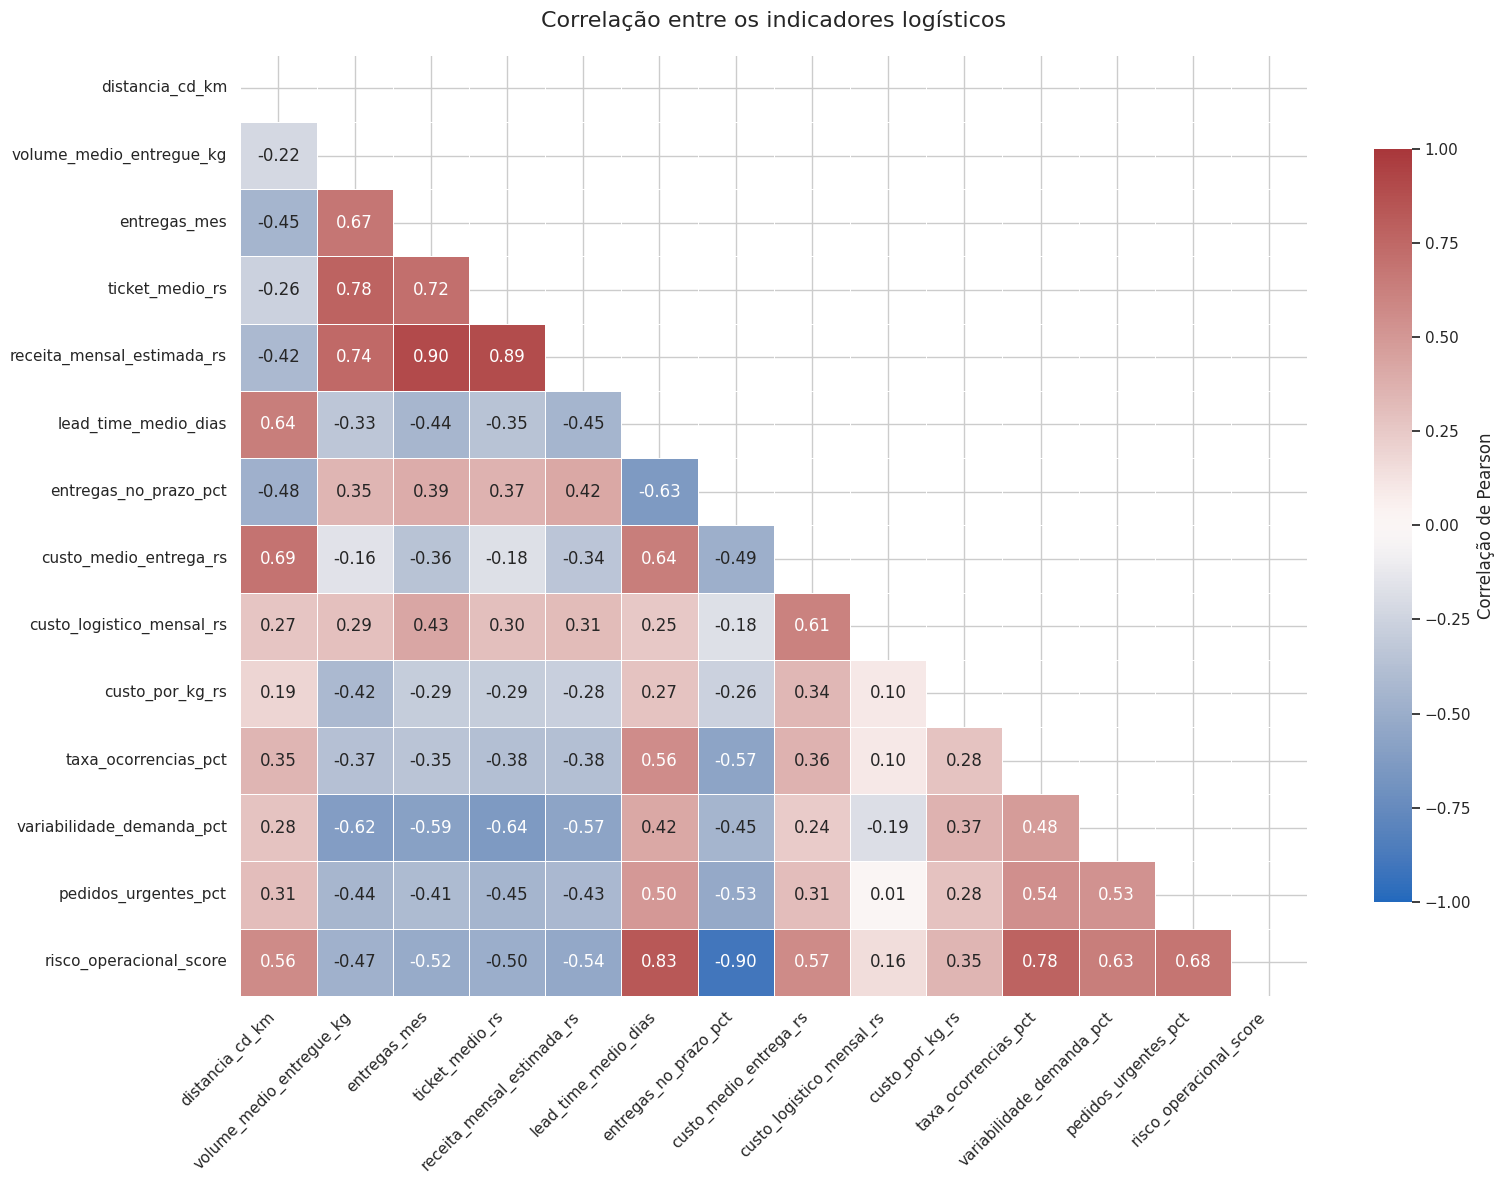

In [13]:
# Calcula a correlação entre as variáveis numéricas operacionais.
matriz_correlacao = clientes_df[colunas_numericas_eda].corr()

# Oculta a parte superior repetida da matriz.
mascara_superior = np.triu(
    np.ones_like(matriz_correlacao, dtype=bool)
)

# Cria o mapa de calor das correlações.
plt.figure(figsize=(16, 12))
sns.heatmap(
    matriz_correlacao,
    mask=mascara_superior,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={
        "shrink": 0.8,
        "label": "Correlação de Pearson",
    },
)

# Ajusta os textos e o layout.
plt.title(
    "Correlação entre os indicadores logísticos",
    fontsize=16,
    pad=20,
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Leitura da matriz de correlação

- A receita mensal possui correlação forte com o número de entregas (0,90), o ticket médio (0,89) e o volume entregue (0,74), refletindo a dimensão econômica e operacional dos clientes.
- O risco operacional apresenta forte relação negativa com as entregas no prazo (-0,90) e relações positivas com lead time (0,83), ocorrências (0,78), pedidos urgentes (0,68) e variabilidade da demanda (0,63).
- A distância possui correlação positiva com o custo médio por entrega (0,69) e com o lead time (0,64), sugerindo maior pressão logística em operações mais distantes.
- Lead time e entregas no prazo apresentam correlação negativa (-0,63), indicando que tempos maiores estão associados a menor nível de serviço neste cenário sintético.

Algumas variáveis carregam informações semelhantes. Ao utilizá-las conjuntamente no K-Means, determinadas dimensões podem ganhar maior peso. As variáveis recomendadas serão mantidas, mas essa dependência será considerada na interpretação e nas limitações do projeto.

Correlação não representa causalidade, especialmente em uma base sintética.

## Preparação das features para clusterização

### Seleção das variáveis

**Objetivo:** selecionar somente indicadores numéricos relacionados ao perfil econômico, operacional, de serviço e de risco dos clientes.

Identificadores, variáveis categóricas e colunas sintéticas de auditoria serão excluídos para evitar vazamento de informação. As variáveis categóricas serão utilizadas posteriormente apenas para interpretar os clusters.

In [14]:
# Define as variáveis numéricas utilizadas na clusterização.
colunas_clusterizacao = [
    "distancia_cd_km",
    "volume_medio_entregue_kg",
    "entregas_mes",
    "ticket_medio_rs",
    "receita_mensal_estimada_rs",
    "lead_time_medio_dias",
    "entregas_no_prazo_pct",
    "custo_medio_entrega_rs",
    "custo_logistico_mensal_rs",
    "custo_por_kg_rs",
    "taxa_ocorrencias_pct",
    "variabilidade_demanda_pct",
    "pedidos_urgentes_pct",
    "risco_operacional_score",
]

# Cria uma cópia independente da matriz de features.
features_df = clientes_df[colunas_clusterizacao].copy()

# Confirma as dimensões e as variáveis selecionadas.
print(
    f"Matriz de features: {features_df.shape[0]} linhas e "
    f"{features_df.shape[1]} colunas."
)
print("\nFeatures selecionadas:")

for coluna in features_df.columns:
    print(f"- {coluna}")

Matriz de features: 6000 linhas e 14 colunas.

Features selecionadas:
- distancia_cd_km
- volume_medio_entregue_kg
- entregas_mes
- ticket_medio_rs
- receita_mensal_estimada_rs
- lead_time_medio_dias
- entregas_no_prazo_pct
- custo_medio_entrega_rs
- custo_logistico_mensal_rs
- custo_por_kg_rs
- taxa_ocorrencias_pct
- variabilidade_demanda_pct
- pedidos_urgentes_pct
- risco_operacional_score


### Padronização das features

**Objetivo:** aplicar o `StandardScaler` para transformar as variáveis em uma escala com média próxima de zero e desvio-padrão próximo de um.

A padronização evita que indicadores com valores monetários ou amplitudes maiores dominem o cálculo das distâncias do K-Means. Ela altera a escala, mas não remove os valores extremos.

In [15]:
# Ajusta o StandardScaler e transforma as features.
scaler = StandardScaler()
features_padronizadas = scaler.fit_transform(features_df)

# Converte o resultado em DataFrame para facilitar a validação.
features_padronizadas_df = pd.DataFrame(
    features_padronizadas,
    columns=colunas_clusterizacao,
    index=clientes_df.index,
)

# Calcula média e desvio-padrão após a transformação.
resumo_padronizacao = pd.DataFrame(
    {
        "media": features_padronizadas_df.mean(),
        "desvio_padrao": features_padronizadas_df.std(ddof=0),
    }
).round(4)

print(
    f"Matriz padronizada: {features_padronizadas_df.shape[0]} linhas e "
    f"{features_padronizadas_df.shape[1]} colunas."
)

resumo_padronizacao

Matriz padronizada: 6000 linhas e 14 colunas.


,media,desvio_padrao
distancia_cd_km,-0.00,1.00
volume_medio_entregue_kg,0.00,1.00
entregas_mes,-0.00,1.00
ticket_medio_rs,0.00,1.00
receita_mensal_estimada_rs,0.00,1.00
lead_time_medio_dias,0.00,1.00
entregas_no_prazo_pct,-0.00,1.00
custo_medio_entrega_rs,0.00,1.00
custo_logistico_mensal_rs,0.00,1.00
custo_por_kg_rs,0.00,1.00


## Definição do número de clusters

### Método do Cotovelo

**Objetivo:** testar diferentes valores de `K` e analisar a redução da inércia do K-Means.

O ponto de cotovelo representa a região em que adicionar novos clusters passa a gerar ganhos progressivamente menores. O resultado será analisado em conjunto com o Silhouette Score e a interpretação de negócio.

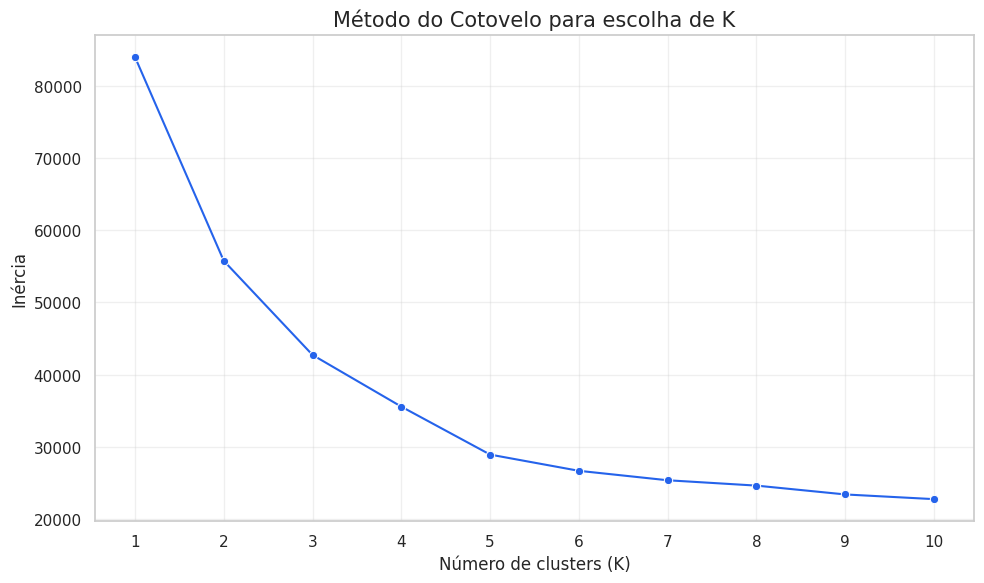

In [16]:
# Define os valores de K que serão avaliados.
valores_k_elbow = range(1, 11)
inercias = []

# Ajusta um modelo K-Means para cada valor de K.
for k in valores_k_elbow:
    modelo_kmeans = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=20,
    )
    modelo_kmeans.fit(features_padronizadas_df)
    inercias.append(modelo_kmeans.inertia_)

# Organiza os resultados obtidos.
resultados_elbow_df = pd.DataFrame(
    {
        "k": list(valores_k_elbow),
        "inercia": inercias,
    }
)

# Cria o gráfico do Método do Cotovelo.
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=resultados_elbow_df,
    x="k",
    y="inercia",
    marker="o",
    color="#2563EB",
)
plt.title("Método do Cotovelo para escolha de K", fontsize=15)
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inércia")
plt.xticks(list(valores_k_elbow))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Leitura do Método do Cotovelo

A inércia diminui de forma acentuada entre `K = 1` e `K = 5`. A partir de cinco clusters, a curva passa a apresentar reduções menores e progressivamente mais estáveis.

Esse comportamento indica `K = 5` como candidato inicial. A escolha ainda não é definitiva e será validada pelo Silhouette Score e pela capacidade de gerar segmentos úteis para o negócio.

### Silhouette Score

**Objetivo:** avaliar a qualidade dos agrupamentos entre `K = 2` e `K = 10`.

O Silhouette Score varia de `-1` a `1`. Valores maiores indicam, em geral, clientes mais semelhantes dentro do próprio cluster e mais distintos dos demais grupos. A métrica será combinada com o Método do Cotovelo e a interpretação de negócio.

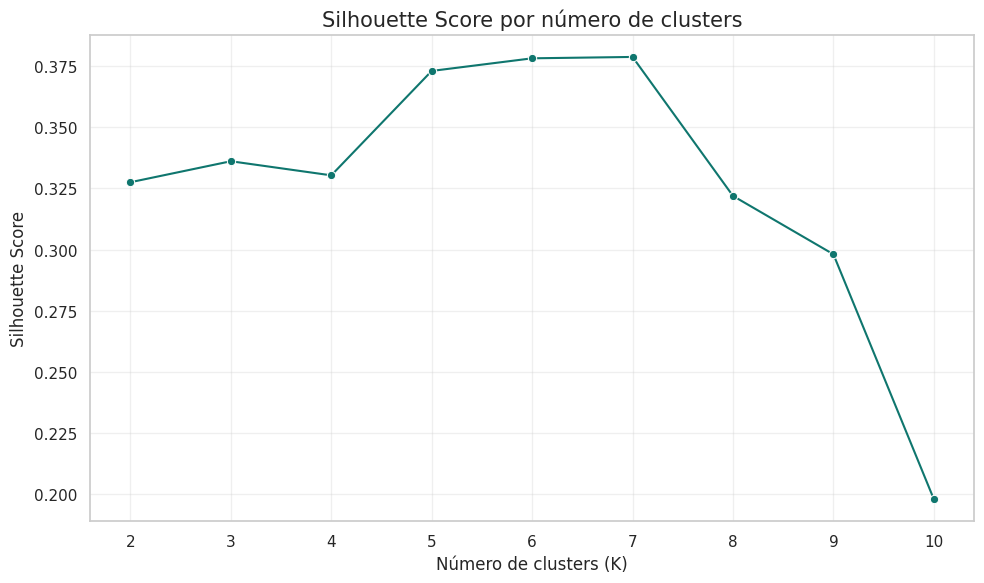

,k,silhouette_score
0,2,0.33
1,3,0.34
2,4,0.33
3,5,0.37
4,6,0.38
5,7,0.38
6,8,0.32
7,9,0.30
8,10,0.20


In [17]:
# Define os valores de K avaliados pelo Silhouette Score.
valores_k_silhouette = range(2, 11)
silhouette_scores = []

# Calcula o Silhouette Score para cada agrupamento.
for k in valores_k_silhouette:
    modelo_kmeans = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=20,
    )
    rotulos = modelo_kmeans.fit_predict(features_padronizadas_df)

    score = silhouette_score(
        features_padronizadas_df,
        rotulos,
    )
    silhouette_scores.append(score)

# Organiza os resultados da avaliação.
resultados_silhouette_df = pd.DataFrame(
    {
        "k": list(valores_k_silhouette),
        "silhouette_score": silhouette_scores,
    }
)

# Cria o gráfico comparativo.
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=resultados_silhouette_df,
    x="k",
    y="silhouette_score",
    marker="o",
    color="#0F766E",
)
plt.title("Silhouette Score por número de clusters", fontsize=15)
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(valores_k_silhouette))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Exibe os valores calculados.
resultados_silhouette_df.round(4)

### Escolha final do número de clusters

O maior Silhouette Score ocorreu em `K = 7`, com resultado muito próximo ao de `K = 6`. Entretanto, `K = 5` também apresentou desempenho semelhante e corresponde ao ponto de estabilização mais evidente no Método do Cotovelo.

A criação de seis ou sete grupos aumentaria a complexidade da análise com ganho limitado de separação. Para manter segmentos mais claros, interpretáveis e acionáveis para o negócio, foi escolhido:

> **Número final de clusters: K = 5**

A decisão equilibra:

- indicação visual do Método do Cotovelo;
- Silhouette Score competitivo;
- menor complexidade;
- melhor capacidade de interpretação gerencial.

As colunas sintéticas de auditoria não foram utilizadas nessa decisão.

## Clusterização final com K-Means

**Objetivo:** aplicar o K-Means com cinco clusters sobre as features padronizadas e registrar o agrupamento de cada cliente.

Os números atribuídos aos clusters são identificadores arbitrários. Eles não representam ordem de qualidade, importância ou risco.

In [18]:
# Define e ajusta o modelo K-Means final.
k_final = 5
modelo_kmeans_final = KMeans(
    n_clusters=k_final,
    random_state=random_state,
    n_init=20,
)

rotulos_clusters = modelo_kmeans_final.fit_predict(
    features_padronizadas_df
)

# Preserva a base original e adiciona os clusters aos resultados.
resultados_df = clientes_df.copy()
resultados_df["cluster_kmeans"] = rotulos_clusters

# Calcula a distribuição dos clientes por cluster.
distribuicao_clusters = (
    resultados_df["cluster_kmeans"]
    .value_counts()
    .sort_index()
    .rename("quantidade")
    .to_frame()
)

distribuicao_clusters["percentual"] = (
    distribuicao_clusters["quantidade"]
    / len(resultados_df)
    * 100
).round(2)

distribuicao_clusters

,quantidade,percentual
cluster_kmeans,,
0,1053,17.55
1,1331,22.18
2,1066,17.77
3,1958,32.63
4,592,9.87


### Métricas do modelo final

**Objetivo:** registrar as métricas do K-Means escolhido para uso na interpretação, conclusão e documentação do projeto.

O Silhouette Score avalia coesão e separação. A inércia mede a distância interna dos clientes aos centroides e deve ser interpretada apenas em comparação com modelos treinados sobre a mesma base padronizada.

In [19]:
# Calcula as métricas do modelo final.
silhouette_final = silhouette_score(
    features_padronizadas_df,
    rotulos_clusters,
)
inercia_final = modelo_kmeans_final.inertia_

# Apresenta os valores com precisão adequada.
print(f"Silhouette Score final: {silhouette_final:.4f}")
print(f"Inércia final: {inercia_final:.2f}")

Silhouette Score final: 0.3730
Inércia final: 28911.61


## Visualização dos clusters com PCA

### Redução de dimensionalidade

**Objetivo:** projetar as features padronizadas em dois componentes principais para permitir uma representação gráfica dos agrupamentos.

O PCA será utilizado somente para visualização. O K-Means foi treinado com todas as 14 features padronizadas.

In [21]:
# Ajusta o PCA para reduzir as features a duas dimensões.
pca = PCA(n_components=2)
componentes_pca = pca.fit_transform(features_padronizadas_df)

# Adiciona os componentes à base de resultados.
resultados_df[["pca_1", "pca_2"]] = componentes_pca

# Calcula a variância explicada pelos componentes.
variancia_explicada_pca = pca.explained_variance_ratio_
variancia_total_pca = variancia_explicada_pca.sum()

# Apresenta a informação preservada na projeção.
print(
    f"Variância explicada pelo PCA 1: "
    f"{variancia_explicada_pca[0]:.2%}"
)
print(
    f"Variância explicada pelo PCA 2: "
    f"{variancia_explicada_pca[1]:.2%}"
)
print(
    f"Variância explicada acumulada: "
    f"{variancia_total_pca:.2%}"
)

Variância explicada pelo PCA 1: 48.04%
Variância explicada pelo PCA 2: 18.23%
Variância explicada acumulada: 66.26%


### Projeção dos clusters em duas dimensões

**Objetivo:** visualizar os agrupamentos definidos pelo K-Means no plano formado pelos dois primeiros componentes principais.

A projeção representa 66,26% da variância dos dados. Portanto, eventuais sobreposições no gráfico não significam necessariamente que os clusters sejam iguais nas 14 dimensões originais.

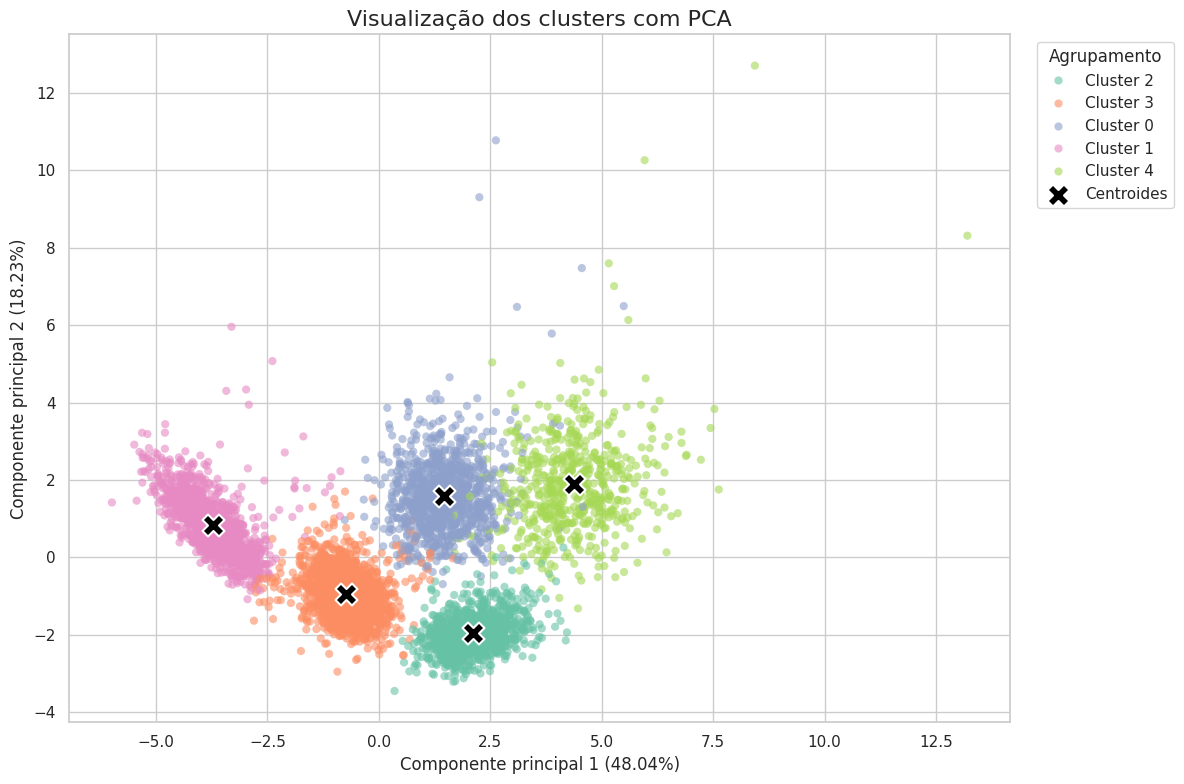

In [22]:
# Cria rótulos legíveis para a visualização.
resultados_df["cluster_visual"] = (
    "Cluster " + resultados_df["cluster_kmeans"].astype(str)
)

# Projeta os centroides do K-Means no plano do PCA.
centroides_pca = pca.transform(
    modelo_kmeans_final.cluster_centers_
)

# Cria o gráfico dos clientes e dos centroides.
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=resultados_df,
    x="pca_1",
    y="pca_2",
    hue="cluster_visual",
    palette="Set2",
    alpha=0.60,
    s=35,
    linewidth=0,
)

plt.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    marker="X",
    s=250,
    color="black",
    edgecolor="white",
    linewidth=1.5,
    label="Centroides",
)

# Ajusta os títulos, eixos e legenda.
plt.title("Visualização dos clusters com PCA", fontsize=16)
plt.xlabel(
    f"Componente principal 1 "
    f"({variancia_explicada_pca[0]:.2%})"
)
plt.ylabel(
    f"Componente principal 2 "
    f"({variancia_explicada_pca[1]:.2%})"
)
plt.legend(
    title="Agrupamento",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

### Leitura da visualização PCA

- Os cinco clusters ocupam regiões relativamente distintas no plano, com centroides visualmente separados.
- Existem áreas de sobreposição próximas às fronteiras, indicando clientes com características intermediárias entre alguns grupos.
- Os clusters 1 e 4 apresentam maior separação ao longo do primeiro componente, enquanto o Cluster 2 se diferencia principalmente pelos valores menores no segundo componente.
- Alguns clientes aparecem distantes das concentrações principais, sinalizando possíveis casos extremos que serão investigados na etapa de anomalias.

A projeção preserva 66,26% da variância. Por isso, a interpretação gerencial dos clusters será baseada nas 14 variáveis originais, e não apenas na posição dos pontos no gráfico.

## Interpretação dos clusters

### Perfil médio dos agrupamentos

**Objetivo:** calcular as médias das 14 variáveis operacionais em cada cluster.

Os valores serão analisados nas unidades originais para transformar os agrupamentos matemáticos em perfis logísticos compreensíveis para o negócio.

In [23]:
# Calcula a média das variáveis originais em cada cluster.
perfil_medio_clusters = (
    resultados_df
    .groupby("cluster_kmeans")[colunas_clusterizacao]
    .mean()
    .round(2)
)

# Transpõe a tabela para facilitar a comparação.
perfil_medio_clusters.T

cluster_kmeans,0,1,2,3,4
distancia_cd_km,358.84,44.60,147.68,95.04,260.19
volume_medio_entregue_kg,789.61,"1,353.25",235.85,653.30,522.66
entregas_mes,6.97,18.14,4.13,10.06,8.04
ticket_medio_rs,"5,186.59","9,235.11","1,588.22","4,339.03","3,578.76"
receita_mensal_estimada_rs,"36,154.90","167,208.30","6,577.13","43,658.18","29,041.74"
lead_time_medio_dias,4.64,1.62,3.16,2.42,6.22
entregas_no_prazo_pct,83.66,95.76,86.78,90.92,67.16
custo_medio_entrega_rs,702.27,213.37,311.42,261.44,604.11
custo_logistico_mensal_rs,"4,912.76","3,861.81","1,280.18","2,625.88","4,863.83"
custo_por_kg_rs,1.04,0.17,1.72,0.45,1.89


### Perfil padronizado dos clusters

**Objetivo:** comparar as médias padronizadas das 14 features em cada agrupamento.

Valores positivos indicam médias acima da base geral, enquanto valores negativos indicam médias abaixo. Estar acima da média não significa necessariamente melhor desempenho, especialmente para custo, lead time, ocorrências e risco.

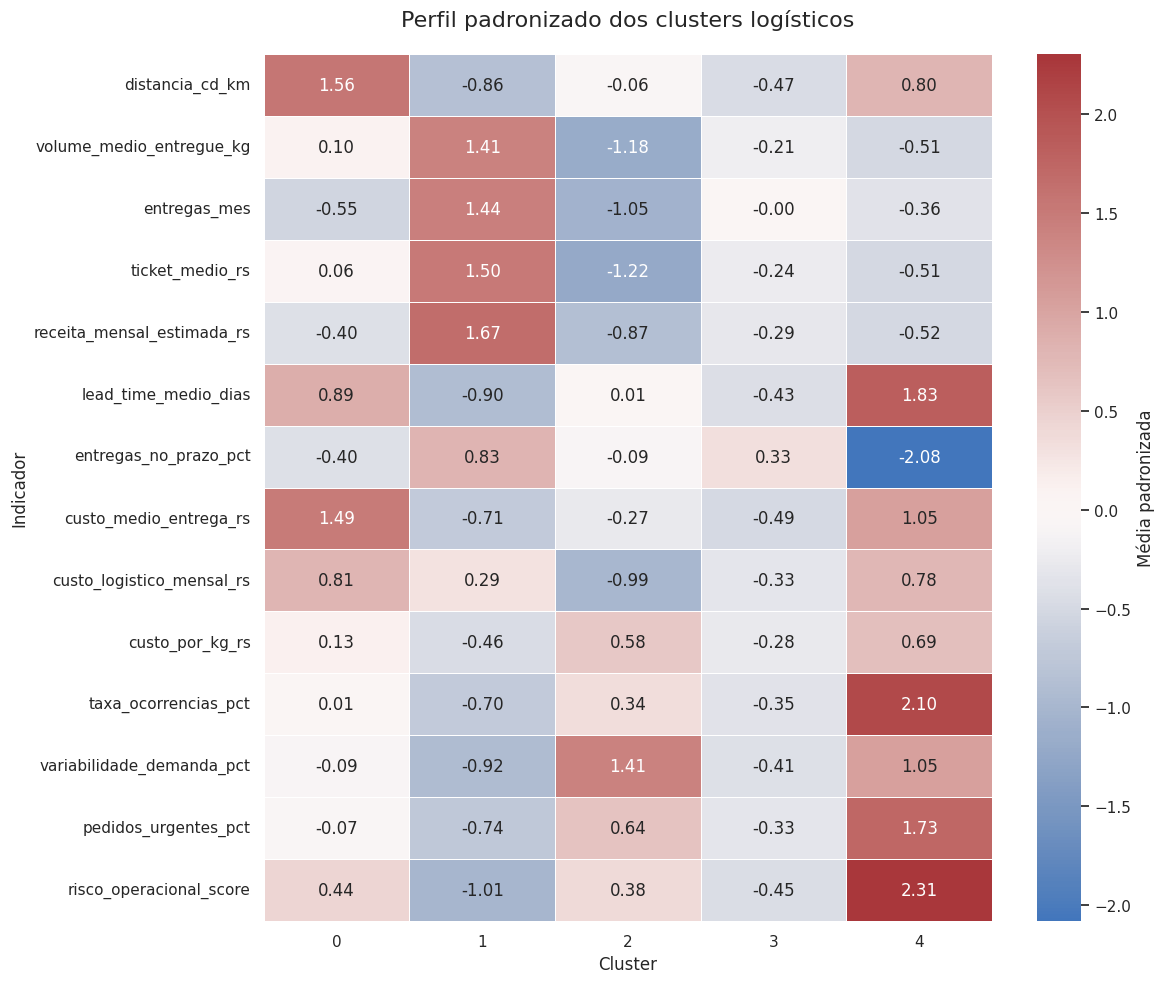

In [24]:
# Cria uma base padronizada com os rótulos dos clusters.
perfil_padronizado_df = features_padronizadas_df.copy()
perfil_padronizado_df["cluster_kmeans"] = rotulos_clusters

# Calcula a média padronizada de cada cluster.
perfil_padronizado_clusters = (
    perfil_padronizado_df
    .groupby("cluster_kmeans")
    .mean()
)

# Cria o mapa de calor dos perfis.
plt.figure(figsize=(12, 10))
sns.heatmap(
    perfil_padronizado_clusters.T,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Média padronizada"},
)

# Ajusta os títulos e o layout.
plt.title(
    "Perfil padronizado dos clusters logísticos",
    fontsize=16,
    pad=20,
)
plt.xlabel("Cluster")
plt.ylabel("Indicador")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Nomes gerenciais dos clusters

**Objetivo:** atribuir nomes descritivos aos agrupamentos com base em seus perfis médios originais e padronizados.

Os nomes não representam classificações definitivas. Eles foram criados para facilitar a interpretação e não utilizaram as colunas sintéticas de auditoria.

In [25]:
# Define os nomes gerenciais com base nos perfis observados.
nomes_clusters = {
    0: "Longa distância e alto custo",
    1: "Estratégicos de alto valor",
    2: "Baixo volume e demanda instável",
    3: "Recorrentes padrão",
    4: "Críticos operacionais",
}

# Adiciona os nomes gerenciais à base de resultados.
resultados_df["perfil_cluster"] = (
    resultados_df["cluster_kmeans"].map(nomes_clusters)
)

# Consolida tamanho, participação e nome de cada cluster.
resumo_gerencial_clusters = distribuicao_clusters.reset_index()
resumo_gerencial_clusters["perfil_cluster"] = (
    resumo_gerencial_clusters["cluster_kmeans"]
    .map(nomes_clusters)
)

resumo_gerencial_clusters = resumo_gerencial_clusters[
    [
        "cluster_kmeans",
        "perfil_cluster",
        "quantidade",
        "percentual",
    ]
]

resumo_gerencial_clusters

,cluster_kmeans,perfil_cluster,quantidade,percentual
0,0,Longa distância e alto custo,1053,17.55
1,1,Estratégicos de alto valor,1331,22.18
2,2,Baixo volume e demanda instável,1066,17.77
3,3,Recorrentes padrão,1958,32.63
4,4,Críticos operacionais,592,9.87


### Perfil categórico complementar

**Objetivo:** identificar a categoria mais frequente dentro de cada cluster para enriquecer sua interpretação gerencial.

Essas variáveis não participaram do treinamento do K-Means. Elas serão utilizadas apenas como informações complementares após a clusterização.

In [26]:
# Cria a tabela que receberá as categorias predominantes.
resumo_categorico_clusters = pd.DataFrame(
    index=sorted(resultados_df["cluster_kmeans"].unique())
)

# Identifica a categoria mais frequente em cada cluster.
for coluna in colunas_categoricas_eda:
    proporcoes = pd.crosstab(
        resultados_df["cluster_kmeans"],
        resultados_df[coluna],
        normalize="index",
    ).mul(100)

    resumo_categorico_clusters[coluna] = proporcoes.apply(
        lambda linha: (
            f"{linha.idxmax()} ({linha.max():.1f}%)"
        ),
        axis=1,
    )

# Identifica o índice da tabela.
resumo_categorico_clusters.index.name = "cluster_kmeans"

resumo_categorico_clusters

,regiao,segmento_negocio,canal_relacionamento,porte_cliente,prioridade_contrato
cluster_kmeans,,,,,
0,Norte (23.4%),Varejo (31.4%),B2B (43.1%),Pequeno (44.3%),Média (61.3%)
1,Sudeste (50.6%),Varejo (32.9%),B2B (41.8%),Pequeno (42.1%),Premium (56.3%)
2,Sudeste (35.8%),Varejo (31.8%),B2B (43.2%),Pequeno (43.3%),Baixa (69.5%)
3,Sudeste (41.0%),Varejo (31.7%),B2B (41.6%),Pequeno (43.1%),Média (71.2%)
4,Sudeste (29.1%),Varejo (32.4%),B2B (42.7%),Pequeno (41.6%),Média (47.5%)


### Leitura do perfil categórico

- A prioridade contratual é a variável categórica que mais diferencia os grupos: o Cluster 1 possui predominância premium, enquanto o Cluster 2 concentra contratos de baixa prioridade.
- O Cluster 0 apresenta maior presença relativa da região Norte, mas o percentual de 23,4% não representa maioria absoluta, indicando dispersão geográfica.
- Varejo, B2B e clientes pequenos aparecem como categorias predominantes em todos os clusters, com percentuais semelhantes.
- Essas repetições refletem a composição geral da base e não são suficientes para explicar isoladamente os agrupamentos.

Portanto, a segmentação foi determinada principalmente pelos indicadores numéricos de valor, volume, custo, serviço e risco. As categorias funcionam apenas como contexto complementar.

### Interpretação gerencial e recomendações

Os valores apresentados são médias de cada cluster.

| Cluster | Perfil e participação | Diagnóstico gerencial | Ação recomendada |
|---:|---|---|---|
| 0 | **Longa distância e alto custo** — 17,55% | Distância média de 358,84 km, custo médio por entrega de R\$ 702,27 e custo logístico mensal de R\$ 4.912,76. | Revisar rotas, política de frete, consolidação de cargas e viabilidade econômica do atendimento. |
| 1 | **Estratégicos de alto valor** — 22,18% | Maior volume, frequência e receita mensal, combinados com pontualidade de 95,76% e risco operacional de 11,41. | Preservar SLA prioritário, garantir capacidade operacional e desenvolver ações de retenção. |
| 2 | **Baixo volume e demanda instável** — 17,77% | Menor volume e receita, variabilidade de 48,92% e custo por kg de R\$ 1,72. | Incentivar consolidação de pedidos, revisar lotes mínimos e melhorar o planejamento da demanda. |
| 3 | **Recorrentes padrão** — 32,63% | Maior grupo, com frequência média, custo controlado, pontualidade de 90,92% e risco de 19,24. | Padronizar e automatizar o atendimento, mantendo monitoramento regular dos indicadores. |
| 4 | **Críticos operacionais** — 9,87% | Lead time de 6,22 dias, pontualidade de 67,16%, ocorrências de 14,57%, urgência de 53,30% e risco de 57,80. | Priorizar diagnóstico de causa raiz, revisar rotas e SLA e criar plano de ação operacional imediato. |

Os clusters apoiam a priorização gerencial, mas não representam uma verdade absoluta nem demonstram relações causais.